!apt-get install x11-utils

!apt-get install x11-utils > /dev/null 2>&1
!pip install pyglet > /dev/null 2>&1
!apt-get install -y xvfb python-opengl > /dev/null 2>&1


!pip install pyvirtualdisplay

from IPython import display as ipythondisplay


from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()


# Deep RL (DQN)
---
We'll use OpenAI Gym: LunarLander-v2 environment to implement a Deep Reinforcement Learning agent (with DQN).




In [ ]:
!pip3 install box2d box2d-kengz

In [ ]:
!pip install -r requirements.txt

In [ ]:
### 1. Imports and installs

!pip install torch==1.10.0

!pip3 install --upgrade Box2D
!pip3 install --upgrade box2d-py
# !pip3 install gym[all] # Has lots of other requirements (mujoco, etc)
!pip3 install --upgrade gym==0.21.0
!pip3 install --upgrade pyglet pygame

In [1]:
!pip install --upgrade gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 6.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gymnasium]


In [2]:
!pip3 install --upgrade Box2D


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 4.5 MB/s  0:00:00m 5.2 MB/s eta 0:00:01


In [3]:
!pip3 install --upgrade gymnasium
!pip3 install --upgrade torch
!pip3 install --upgrade pyglet pygame

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 5.2 MB/s  0:00:005.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 5.0 MB/s  0:00:02m 5.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pygame]━━━━ 1/2 [pygame]


In [1]:
import gymnasium as gym
#import gym
import random
import torch
import numpy as np
import base64, io
from collections import deque
import matplotlib.pyplot as plt
%matplotlib inline

### 2. Create Environment


We create the required GYM environment (code is almost environment agnostic, can be used with other environs).


env = gym.make('LunarLander-v3')
# env.seed(42)

# Information on the environment
print('State shape: ', env.observation_space.shape)
print('Number of actions: ', env.action_space.n)

# How a "random" agent works


# watch an untrained agent
state = env.reset()
for j in range(200):
    action = agent.act(state)
    env.render()
    state, reward, done, _ = env.step(action)
    if done:
        break
        
env.close()

In [2]:
#import gym
env = gym.make("LunarLander-v3") #, render_mode="human")
observation, info = env.reset(seed=123, options={})

from dqn_agent import Agent

agent = Agent(state_size=8, action_size=4, seed=42)

done = False
while not done:
    #action = env.action_space.sample()  # agent policy that uses the observation and info
    action = agent.act(observation)

    observation, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

env.close()


/Users/carlesm/.virtualenvs/classe/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


mps


### 3. Deep Reinforcement Learning (DQN)



In [3]:
def dqn(episodes=2000, time_steps=1500, eps_start=1.0, eps_end=0.01, eps_decay=0.995):
    """
      Deep RL DQN.
      Runs for <episodes> storing scores on <scores>, last 100 scores on <scores_window> for showing


     :param episodes:  (int) Maximum training episodes
     :param time_steps: (int) Max timesteps
     :param eps_start: (float) Epsilon initial
     :param eps_end: (float) Epsilon final
     :param eps_decay: (float) Epsilon decay
    """
    scores = []                        # list containing scores from each episode
    scores_window = deque(maxlen=100)  # last 100 scores
    eps = eps_start                    # initialize epsilon
    for i_episode in range(1, episodes+1):
        observation, info = env.reset(seed=123, options={}) # +i_episode
        score = 0
        for t in range(time_steps):
            action = agent.act(observation, eps)
            next_observation, reward, terminated, truncated, info = env.step(action)
            agent.step(observation, action, reward, next_observation, done)
            observation = next_observation
            score += reward
            if terminated:
                break
        scores_window.append(score)       # save most recent score
        scores.append(score)              # save most recent score
        eps = max(eps_end, eps_decay*eps) # decrease epsilon
        print('\rEpisode {}\tAverage Score: {:.2f}'.format(i_episode, np.mean(scores_window)), end="")
        if i_episode % 100 == 0:
            print('\rEpisode {}\tAverage Score: {:.2f}'.format(i_episode, np.mean(scores_window)))
            torch.save(agent.qnet_local.state_dict(), 'checkpoint.pth')

        if np.mean(scores_window)>=200.0:
            print('\nEnvironment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(i_episode-100, np.mean(scores_window)))
            torch.save(agent.qnet_local.state_dict(), 'checkpoint.pth')
            break
    return scores


In [4]:
env = gym.make("LunarLander-v3", render_mode=None)
observation, info = env.reset(seed=123, options={})

scores = dqn()


Episode 100	Average Score: -171.47
Episode 200	Average Score: -242.16
Episode 300	Average Score: -299.49
Episode 400	Average Score: -239.74
Episode 500	Average Score: -219.64
Episode 600	Average Score: -309.92
Episode 700	Average Score: -235.80
Episode 800	Average Score: -171.22
Episode 900	Average Score: -127.57
Episode 1000	Average Score: -81.59
Episode 1100	Average Score: -118.45
Episode 1200	Average Score: -67.586
Episode 1300	Average Score: -60.79
Episode 1400	Average Score: -41.31
Episode 1500	Average Score: -169.88
Episode 1600	Average Score: -148.24
Episode 1700	Average Score: -122.31
Episode 1800	Average Score: -83.627
Episode 1900	Average Score: -43.84
Episode 2000	Average Score: -25.18


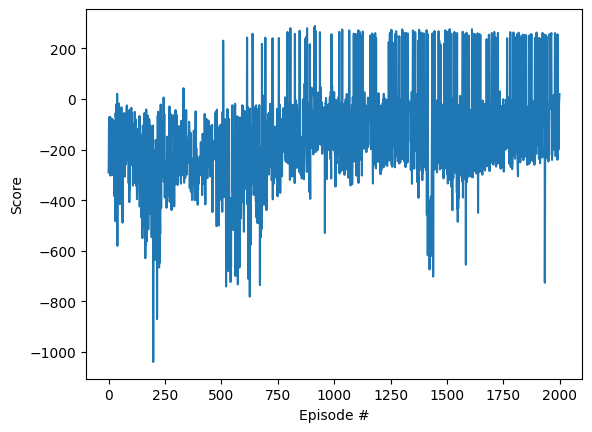

In [5]:

# plot
fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(np.arange(len(scores)), scores)
plt.ylabel('Score')
plt.xlabel('Episode #')
plt.show()

In [6]:
observation, info = env.reset(seed=123, options={})

scores.append(dqn())


Episode 100	Average Score: -89.70
Episode 200	Average Score: -89.78
Episode 300	Average Score: -108.38
Episode 400	Average Score: -85.894
Episode 500	Average Score: -96.547
Episode 600	Average Score: -78.462
Episode 700	Average Score: -31.89
Episode 800	Average Score: -90.07
Episode 900	Average Score: -103.13
Episode 1000	Average Score: -48.33
Episode 1100	Average Score: -72.17
Episode 1200	Average Score: -13.37
Episode 1300	Average Score: -30.06
Episode 1400	Average Score: -42.49
Episode 1500	Average Score: 8.1655
Episode 1600	Average Score: -17.83
Episode 1700	Average Score: -1.600
Episode 1800	Average Score: -28.12
Episode 1900	Average Score: -22.71
Episode 2000	Average Score: 10.504


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2001,) + inhomogeneous part.

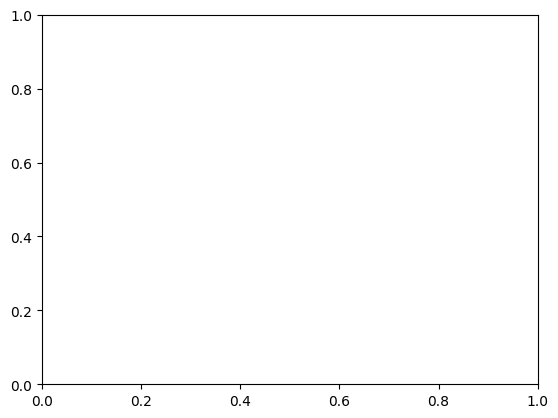

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(np.arange(len(scores)), scores)
plt.ylabel('Score')
plt.xlabel('Episode #')
plt.show()


In [ ]:


# load the weights from file
agent.qnet_local.load_state_dict(torch.load('checkpoint-Copy1.pth'))
env = gym.make("LunarLander-v3", render_mode="human")
observation, info = env.reset(seed=123, options={})

for i in range(5):
    state,info = env.reset(seed=123, options={})
    for j in range(1000):
        action = agent.act(state)
        env.render()
        state, reward, terminated, truncated, info = env.step(action)
        if terminated:
            break

env.close()



import torch

if torch.backends.mps.is_available():
    mps_device=torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print("No MPS")

In [13]:
import gymnasium as gym

from gymnasium.wrappers import RecordVideo
agent.qnet_local.load_state_dict(torch.load('checkpoint.pth'))
env2 = gym.make("LunarLander-v3", render_mode="rgb_array")
env = gym.wrappers.RecordVideo(env=env2, video_folder="./videos", name_prefix="lunar", episode_trigger=lambda x: x == x)
# env.start_video_recorder()


for i in range(5):
    state,info = env.reset(seed=123, options={})
    for j in range(1000):
        action = agent.act(state)
        state, reward, terminated, truncated, info = env.step(action)
        if terminated or truncated:
            break

#env.close_video_recorder()
env.close()


/Users/carlesm/.virtualenvs/classe/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/carlesm/tmp/drl/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


!pip install "gymnasium[other]"

In [24]:
!pip install "gymnasium[other]"

  Using cached pillow-11.3.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 10.5 MB/s  0:00:000.8 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 10.6 MB/s  0:00:010.7 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 10.8 MB/s  0:00:03 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 10.4 MB/s  0:00:000.7 MB/s eta 0:00:01
  Attempting uninstall: pillow
    Found existing installation: pillow 12.0.0
    Uninstalling pillow-12.0.0:
      Successfully uninstalled pillow-12.0.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.4
    Uninstalling numpy-2.3.4:
      Successfully uninstalled numpy-2.3.4;237m╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/7 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [moviepy]━━━━━━━━━━ 5/7 [imageio]ython]


from gym.wrappers import RecordVideo
agent.qnet_local.load_state_dict(torch.load('checkpoint-Copy1.pth'))
env2 = gym.make("LunarLander-v3", render_mode="rgb_array")
env = gym.wrappers.RecordVideo(env=env2, video_folder="./", name_prefix="lunar", episode_trigger=lambda x: x == x)
# env.start_video_recorder()

observation, info = env.reset(seed=123, options={})

for i in range(5):
    state,info = env.reset(seed=123, options={})
    for j in range(1000):
        action = agent.act(state)
        env.render()
        state, reward, terminated, truncated, info = env.step(action)
        if terminated:
            break

#env.close_video_recorder()
env.close()